In [156]:
import numpy as np
import matplotlib.pyplot as plt

# Define the sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [157]:
# Loss function: Log likelihood
def compute_loss(y, hx):
    return -np.mean(y * np.log(hx) + (1 - y) * np.log(1 - hx))

In [158]:
# Gradient descent for logistic regression
def compute_gradient(X, y, hx):
    return np.dot(X.T, (hx - y)) / y.shape[0]

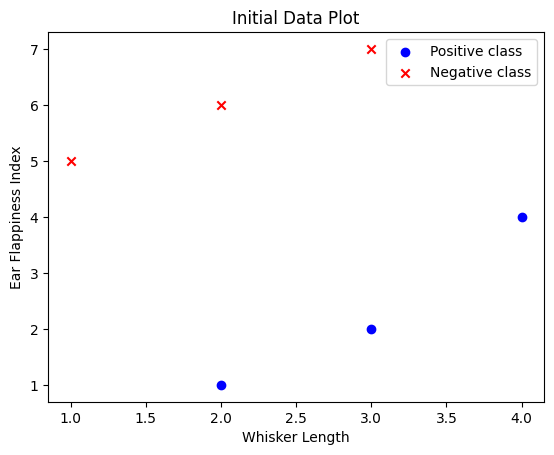

In [159]:
# Data set
X = np.array([
    [2, 1],
    [3, 2],
    [4, 4], # Positive examples
    [1, 5], 
    [2, 6], 
    [3, 7]] # Negative examples
)
y = np.array([1, 1, 1, 0, 0, 0])

# Plot initial data
plt.scatter(X[:3, 0], X[:3, 1], color='blue', marker = 'o', label='Positive class')
plt.scatter(X[3:, 0], X[3:, 1], color='red', marker = 'x', label='Negative class')
plt.xlabel('Whisker Length')
plt.ylabel('Ear Flappiness Index')
plt.legend()
plt.title('Initial Data Plot')
plt.show()

In [160]:
def plot_decision_boundary(X, y, weights, loss, iteration):
    plt.scatter(X[:3, 1], X[:3, 2], color='blue', marker = 'o', label='Positive class' if iteration == 0 else "")
    plt.scatter(X[3:, 1], X[3:, 2], color='red', marker = 'x', label='Negative class' if iteration == 0 else "")

    # Extend the x values a bit beyond the data range for better visualization
    x_values = np.array([np.min(X[:, 1]) - 1, np.max(X[:, 1]) + 1])
    y_values = -(weights[0] + weights[1] * x_values) / weights[2]
    plt.plot(x_values, y_values, "k")

    plt.xlim(x_values[0], x_values[1])
    plt.ylim(np.min(X[:, 2]) - 1, np.max(X[:, 2]) + 1)
    plt.xlabel('Whisker Length')
    plt.ylabel('Ear Flappiness Index')
    plt.title(f'Iteration {iteration}, Loss: {loss}')
    if iteration == 0:
        plt.legend()
    plt.show()

In [161]:
def Logistic_Regression(X, y, learning_rate=0.1, num_iterations=10):
    # Add intercept term to X
    X = np.hstack((np.ones((X.shape[0], 1)), X))

    # Initialize weights
    weights = np.zeros(X.shape[1])

    # Gradient descent
    for i in range(num_iterations):
        z = np.dot(X, weights)
        hx = sigmoid(z)
        loss = compute_loss(y, hx)
        gradient = compute_gradient(X, y, hx)
        weights -= learning_rate * gradient

        plot_decision_boundary(X, y, weights, loss, i)
        print(f"Iteration {i+1}: Theta = {weights}, Loss = {loss}")

    return weights

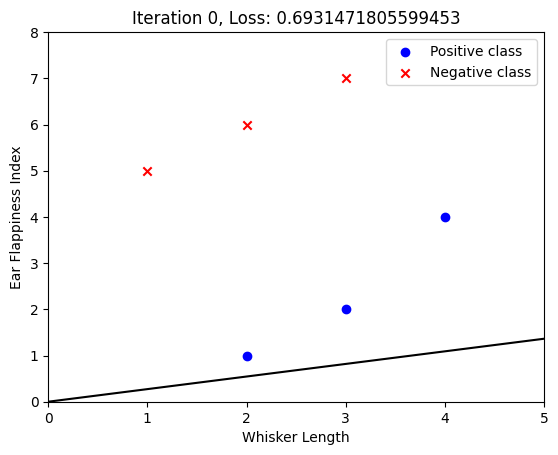

Iteration 1: Theta = [ 0.          0.025      -0.09166667], Loss = 0.6931471805599453


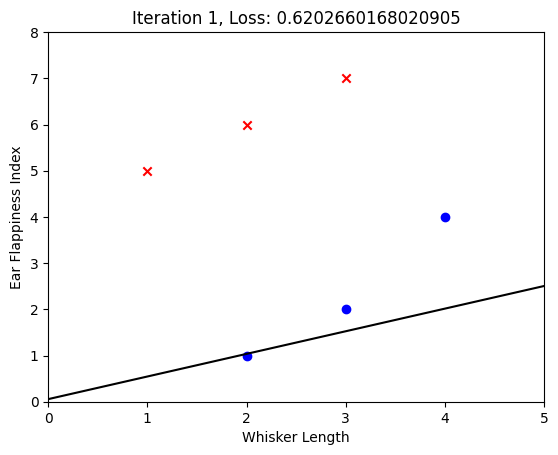

Iteration 2: Theta = [ 0.00784781  0.06887779 -0.14060525], Loss = 0.6202660168020905


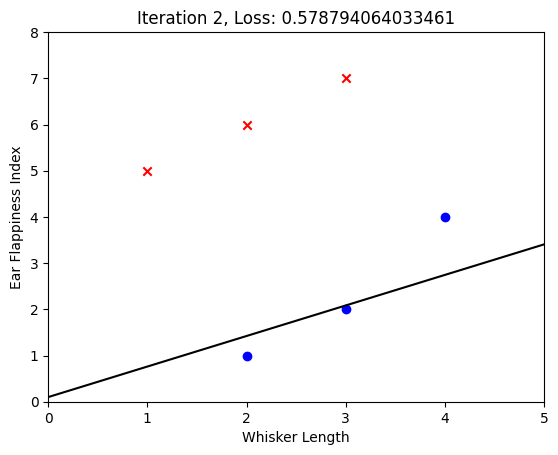

Iteration 3: Theta = [ 0.01764134  0.11658362 -0.17629863], Loss = 0.578794064033461


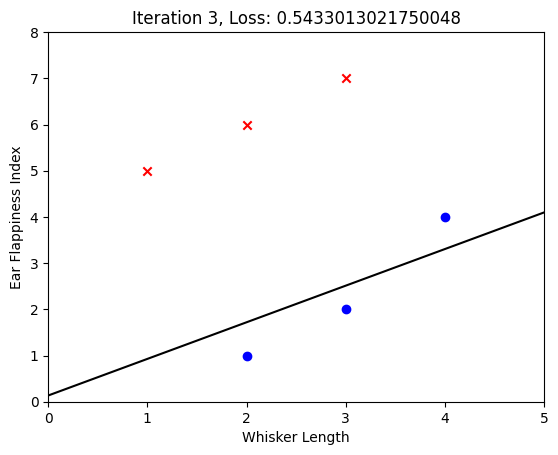

Iteration 4: Theta = [ 0.02775584  0.16401158 -0.20689154], Loss = 0.5433013021750048


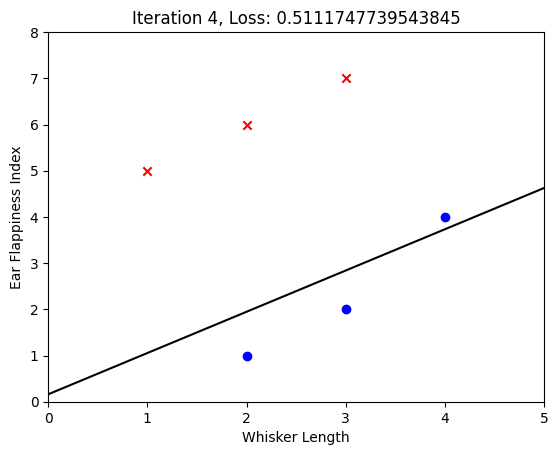

Iteration 5: Theta = [ 0.03768945  0.20992896 -0.23499581], Loss = 0.5111747739543845


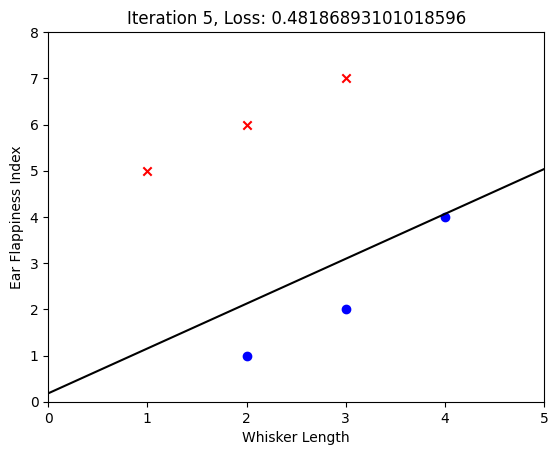

Iteration 6: Theta = [ 0.04728565  0.25399034 -0.26154053], Loss = 0.48186893101018596


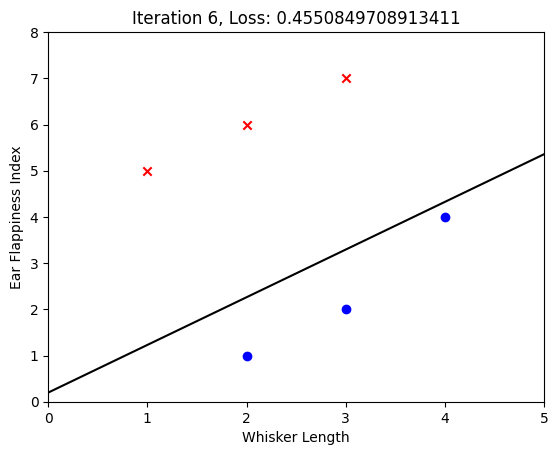

Iteration 7: Theta = [ 0.0565048   0.29615111 -0.28688777], Loss = 0.4550849708913411


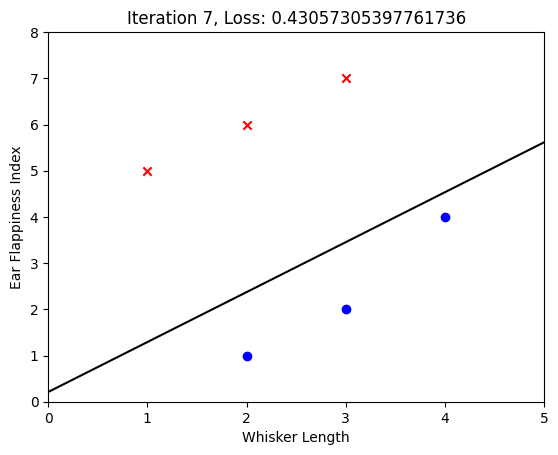

Iteration 8: Theta = [ 0.06534809  0.33647087 -0.31119923], Loss = 0.43057305397761736


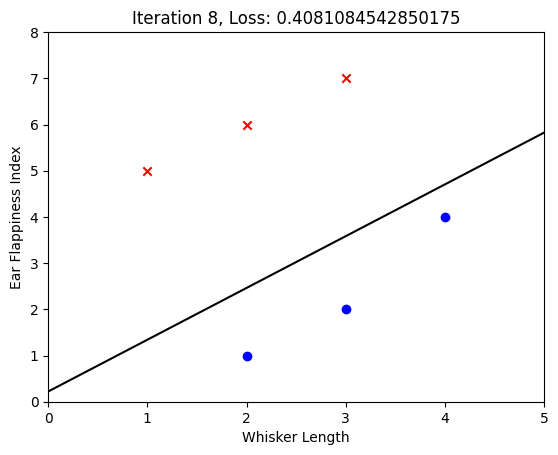

Iteration 9: Theta = [ 0.07383072  0.37504349 -0.3345636 ], Loss = 0.4081084542850175


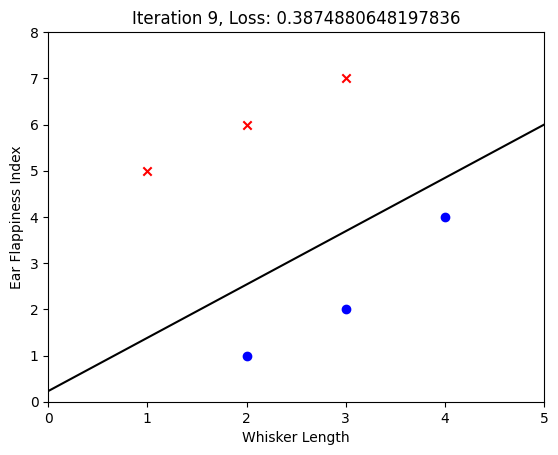

Iteration 10: Theta = [ 0.08197221  0.41197135 -0.35704216], Loss = 0.3874880648197836


In [162]:
# Training the model
weights = Logistic_Regression(X, y)